In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [8]:
df = pd.read_csv("/content/city_day.csv")

df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [9]:
#Check missing values
df.isnull().sum()

,0
City,0
Date,0
PM2.5,4598
PM10,11140
NO,3582
NO2,3585
NOx,4185
NH3,10328
CO,2059
SO2,3854


In [10]:
#Handle missing values
df = df.fillna(method='ffill')
df = df.fillna(method='bfill')

/tmp/ipykernel_158/2155389130.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')
/tmp/ipykernel_158/2155389130.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill')


In [11]:
#Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

In [12]:
#Feature Engineering
#Extract useful time features.
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Year'] = df['Date'].dt.year
df['DayOfWeek'] = df['Date'].dt.dayofweek

In [13]:
#Encode City column
le = LabelEncoder()
df['City'] = le.fit_transform(df['City'])

In [14]:
#Select important features
features = ['PM2.5','PM10','NO2','SO2','CO','O3','City','Month','DayOfWeek']
target = 'AQI'

df = df[features + [target]]

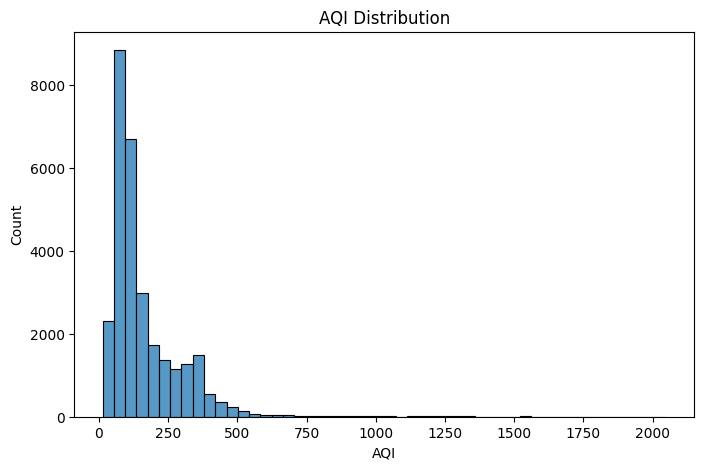

In [15]:
#VISUALISATION
#AQI Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['AQI'], bins=50)
plt.title("AQI Distribution")
plt.show()

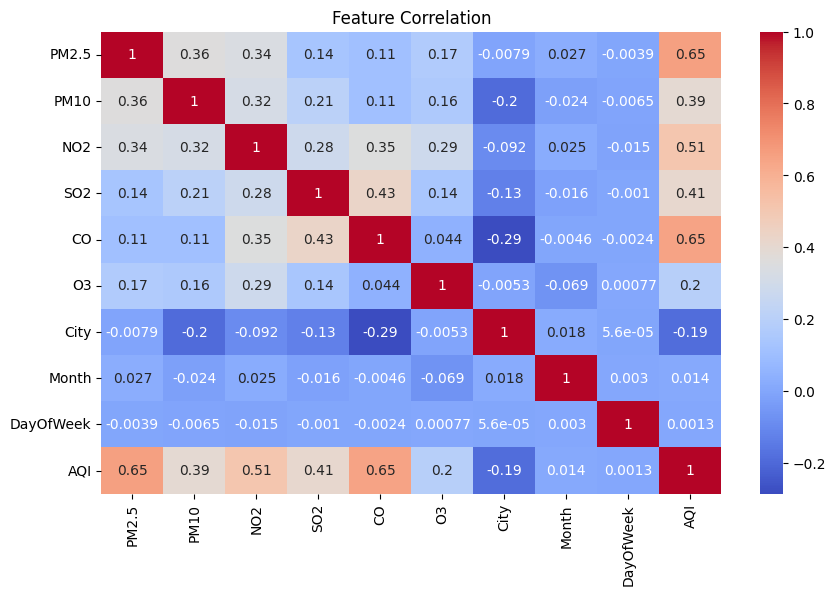

In [16]:
#Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

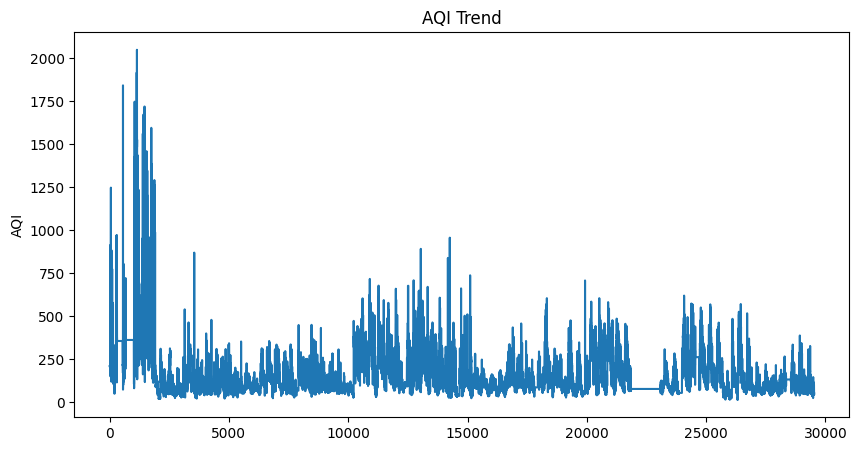

In [17]:
#pollution trend
plt.figure(figsize=(10,5))
sns.lineplot(data=df['AQI'])
plt.title("AQI Trend")
plt.show()

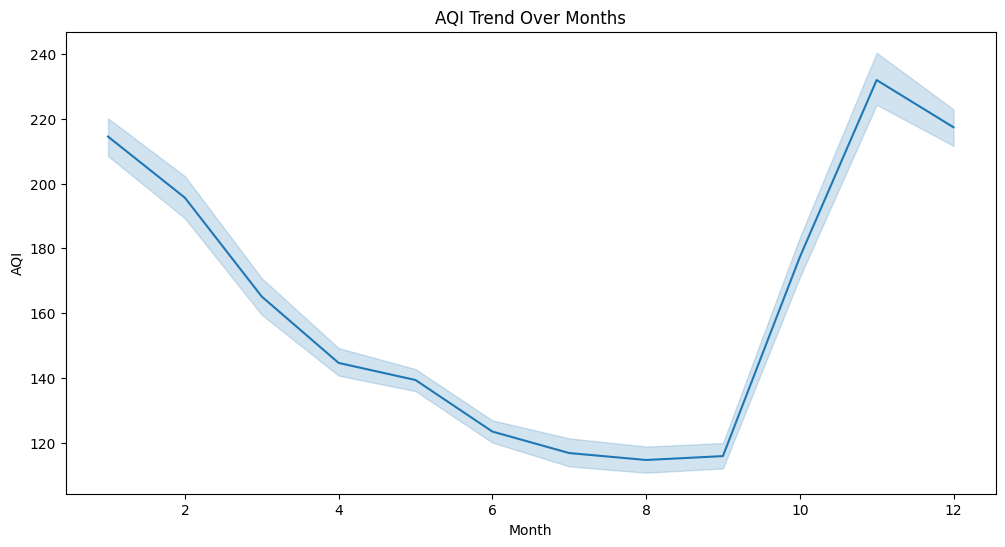

In [36]:
plt.figure(figsize=(12,6))
sns.lineplot(x="Month", y="AQI", data=df)
plt.title("AQI Trend Over Months")
plt.xlabel("Month")
plt.ylabel("AQI")
plt.show()

In [19]:
#Prepare Data for Model
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
#Model Building
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [21]:
#Random Forest
rf = RandomForestRegressor(n_estimators=100)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [22]:
#Gradient Boosting
gb = GradientBoostingRegressor()

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

In [23]:
#Model Evaluation
def evaluate(y_test, y_pred):

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print("RMSE:", rmse)
    print("MAE:", mae)
    print("R2 Score:", r2)

In [25]:
#Linear Regression
evaluate(y_test, y_pred_lr)

RMSE: 58.907169533793116
MAE: 33.96946408952256
R2 Score: 0.8053252068737558


In [26]:
#Random Forest
evaluate(y_test, y_pred_rf)

RMSE: 39.94504267240573
MAE: 19.719781897184134
R2 Score: 0.9104843046398181


In [27]:
#Gradient Boosting
evaluate(y_test, y_pred_gb)

RMSE: 45.67253041797294
MAE: 24.053741875407603
R2 Score: 0.8829736773867207


In [28]:
#Model Optimization
rf_opt = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42
)

rf_opt.fit(X_train, y_train)

y_pred_opt = rf_opt.predict(X_test)

evaluate(y_test, y_pred_opt)

RMSE: 40.213485882706514
MAE: 20.160698545276528
R2 Score: 0.9092771148016008


In [29]:
#Model Deployment
import pickle

pickle.dump(rf_opt, open('aqi_model.pkl','wb'))

In [30]:
#Simple Prediction
model = pickle.load(open('aqi_model.pkl','rb'))

sample = [[50,80,20,10,0.5,30,1,7,2]]

prediction = model.predict(sample)

print("Predicted AQI:", prediction)

Predicted AQI: [98.31650493]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


<Axes: xlabel='AQI_Category', ylabel='count'>

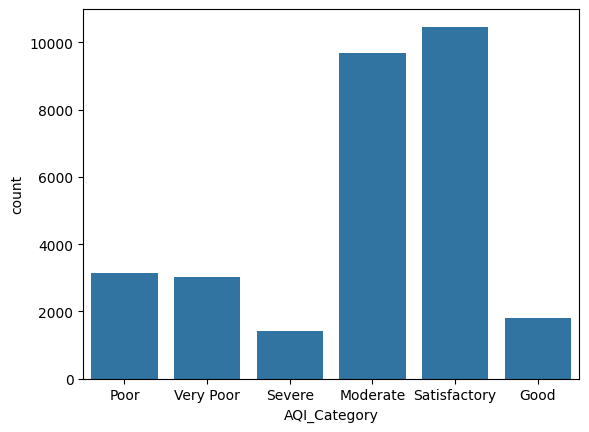

In [38]:
def aqi_category(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Satisfactory"
    elif aqi <= 200:
        return "Moderate"
    elif aqi <= 300:
        return "Poor"
    elif aqi <= 400:
        return "Very Poor"
    else:
        return "Severe"

df['AQI_Category'] = df['AQI'].apply(aqi_category)

sns.countplot(x='AQI_Category', data=df)

<Axes: xlabel='City'>

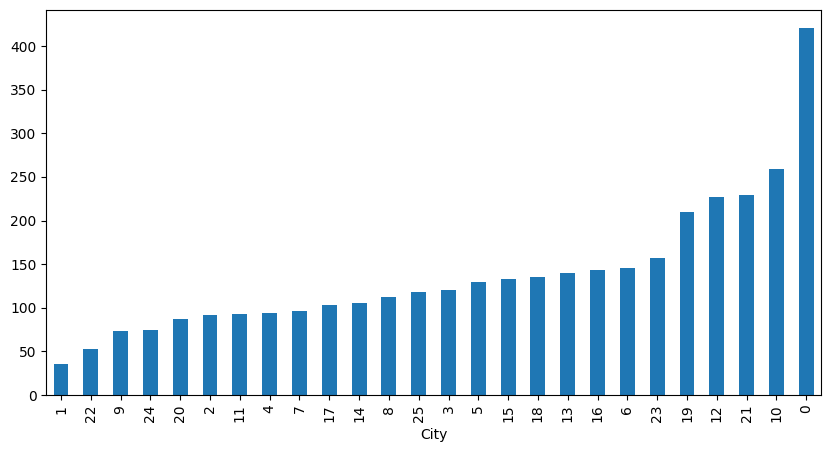

In [39]:
city_pollution = df.groupby('City')['AQI'].mean().sort_values()

city_pollution.plot(kind='bar', figsize=(10,5))

<Axes: xlabel='Importance', ylabel='Feature'>

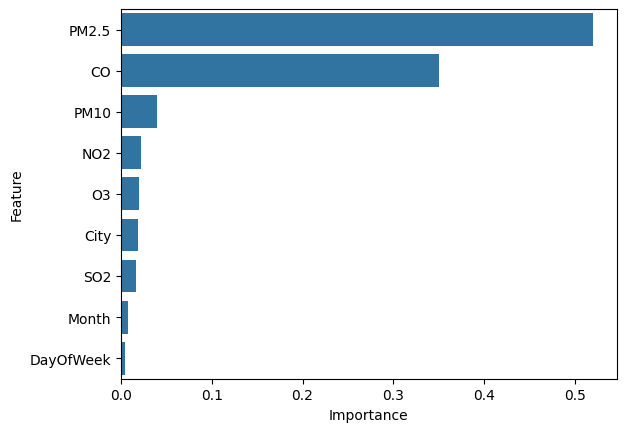

In [40]:
importances = rf.feature_importances_

features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=importance_df)

In [43]:
from google.colab import files
files.download('aqi_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>